# Milestone 3: Text Embeddings and Search

This notebook is a clean, simple Milestone 3 implementation. It loads the processed CSV files, recreates `rating_band` from ratings every time, trains two text classifiers, and runs TF-IDF cosine similarity search.

Milestone 4 is not implemented here.

## Setup

`FAST_MODE` keeps local execution quick by limiting rows and training the embedding model for two epochs.

In [ ]:
from __future__ import annotations

import ast
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")
tf.keras.utils.set_random_seed(42)

FAST_MODE = True
RANDOM_SEED = 42
LABEL_ORDER = ["low", "medium", "high"]

if FAST_MODE:
    TRAIN_MAX_ROWS = 10000
    VALIDATION_MAX_ROWS = 3000
    TEST_MAX_ROWS = 3000
    EPOCHS = 2
else:
    TRAIN_MAX_ROWS = None
    VALIDATION_MAX_ROWS = None
    TEST_MAX_ROWS = None
    EPOCHS = 8

MAX_TOKENS = 10000
SEQUENCE_LENGTH = 80
EMBEDDING_DIM = 64
BATCH_SIZE = 64

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_PATH = PROCESSED_DIR / "train.csv"
VALIDATION_PATH = PROCESSED_DIR / "validation.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"

TEXT_CANDIDATES = ["review_text", "text", "review_body", "body", "content"]
RATING_CANDIDATES = ["review_rating", "rating", "average_rating", "overall", "score"]

print(f"Project root: {PROJECT_ROOT}")
print(f"FAST_MODE: {FAST_MODE}")

## Load Data

Load the train, validation, and test CSV files. The columns are printed so schema problems are easy to see.

In [ ]:
for path in [TRAIN_PATH, VALIDATION_PATH, TEST_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
validation_raw = pd.read_csv(VALIDATION_PATH, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, low_memory=False)

raw_splits = {
    "train": train_raw,
    "validation": validation_raw,
    "test": test_raw,
}

for name, df in raw_splits.items():
    print(f"{name} columns:")
    print(df.columns.tolist())

## Clean Text and Rating Bands

Detect the text column and rating column for each split. Then create exactly three clean classification dataframes: `train_clean`, `validation_clean`, and `test_clean`, each with only `text` and `rating_band` columns.

In [ ]:
def detect_column(df: pd.DataFrame, candidates: list[str], split_name: str, kind: str) -> str:
    column = next((candidate for candidate in candidates if candidate in df.columns), None)
    if column is None:
        raise KeyError(
            f"No {kind} column found for {split_name}. "
            f"Expected one of {candidates}. Available columns: {df.columns.tolist()}"
        )
    return column


def clean_text(value) -> str:
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()


def create_rating_band(rating_values: pd.Series) -> pd.Series:
    ratings = pd.to_numeric(rating_values, errors="coerce")
    bands = pd.Series(pd.NA, index=rating_values.index, dtype="string")
    bands.loc[ratings <= 2] = "low"
    bands.loc[(ratings > 2) & (ratings < 4)] = "medium"
    bands.loc[ratings >= 4] = "high"
    return bands


def limit_rows(df: pd.DataFrame, max_rows: int | None) -> pd.DataFrame:
    if max_rows is None or len(df) <= max_rows:
        return df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return df.sample(n=max_rows, random_state=RANDOM_SEED).reset_index(drop=True)


def make_clean_split(df: pd.DataFrame, split_name: str, max_rows: int | None) -> pd.DataFrame:
    text_col = detect_column(df, TEXT_CANDIDATES, split_name, "text")
    rating_col = detect_column(df, RATING_CANDIDATES, split_name, "rating")
    print(f"{split_name}: text column = {text_col}; rating column = {rating_col}")

    clean_df = pd.DataFrame()
    clean_df["text"] = df[text_col].map(clean_text)
    clean_df["rating_band"] = create_rating_band(df[rating_col])
    clean_df = clean_df[(clean_df["text"].str.len() > 0) & clean_df["rating_band"].notna()].copy()
    clean_df["rating_band"] = clean_df["rating_band"].astype(str)
    clean_df = clean_df[clean_df["rating_band"].isin(LABEL_ORDER)]
    clean_df = clean_df[["text", "rating_band"]]
    clean_df = limit_rows(clean_df, max_rows)
    return clean_df[["text", "rating_band"]]


train_clean = make_clean_split(train_raw, "train", TRAIN_MAX_ROWS)
validation_clean = make_clean_split(validation_raw, "validation", VALIDATION_MAX_ROWS)
test_clean = make_clean_split(test_raw, "test", TEST_MAX_ROWS)

for name, df in {"train": train_clean, "validation": validation_clean, "test": test_clean}.items():
    print(f"{name}: {df.shape}")
    print(df["rating_band"].value_counts())
    assert df.columns.tolist() == ["text", "rating_band"]

## Encode Labels

Map rating bands to integer labels for scikit-learn and Keras.

In [ ]:
observed_labels = [label for label in LABEL_ORDER if label in set(train_clean["rating_band"])]
if len(observed_labels) < 2:
    raise ValueError("Training data must contain at least two rating bands.")

label_to_id = {label: index for index, label in enumerate(observed_labels)}

validation_clean = validation_clean[validation_clean["rating_band"].isin(label_to_id)].reset_index(drop=True)
test_clean = test_clean[test_clean["rating_band"].isin(label_to_id)].reset_index(drop=True)

X_train_text = train_clean["text"].to_numpy(dtype=str)
y_train = train_clean["rating_band"].map(label_to_id).to_numpy(dtype="int32")
X_validation_text = validation_clean["text"].to_numpy(dtype=str)
y_validation = validation_clean["rating_band"].map(label_to_id).to_numpy(dtype="int32")
X_test_text = test_clean["text"].to_numpy(dtype=str)
y_test = test_clean["rating_band"].map(label_to_id).to_numpy(dtype="int32")

print("Labels:", observed_labels)

# Part A: TF-IDF + Logistic Regression

Train a simple TF-IDF baseline and report accuracy, macro F1, a classification report, and a confusion matrix.

In [5]:
tfidf_model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)),
    ]
)

tfidf_model.fit(X_train_text, y_train)
tfidf_pred = tfidf_model.predict(X_test_text)

print(f"TF-IDF accuracy: {accuracy_score(y_test, tfidf_pred):.4f}")
print(f"TF-IDF macro F1: {f1_score(y_test, tfidf_pred, average='macro', zero_division=0):.4f}")
print(classification_report(y_test, tfidf_pred, labels=list(range(len(observed_labels))), target_names=observed_labels, zero_division=0))

TF-IDF accuracy: 0.8120
TF-IDF macro F1: 0.6512
              precision    recall  f1-score   support

         low       0.64      0.71      0.67       450
      medium       0.34      0.43      0.38       273
        high       0.93      0.88      0.90      2277

    accuracy                           0.81      3000
   macro avg       0.64      0.67      0.65      3000
weighted avg       0.83      0.81      0.82      3000



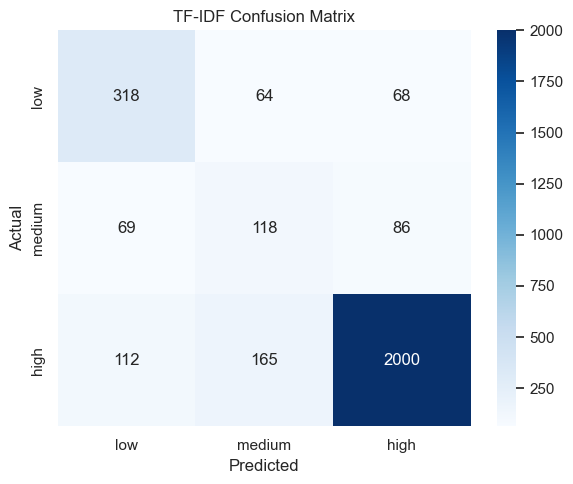

In [6]:
def show_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(observed_labels))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=observed_labels, yticklabels=observed_labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


show_confusion_matrix(y_test, tfidf_pred, "TF-IDF Confusion Matrix")

# Part B: Simple Keras Embedding Model

Train a compact neural network with `TextVectorization`, `Embedding`, `GlobalAveragePooling1D`, dense layers, dropout, and softmax output.

In [7]:
X_train_text = [str(x) for x in X_train_text]
X_validation_text = [str(x) for x in X_validation_text]
X_test_text = [str(x) for x in X_test_text]

y_train = np.asarray(y_train, dtype="int32")
y_validation = np.asarray(y_validation, dtype="int32")
y_test = np.asarray(y_test, dtype="int32")

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
)

vectorizer.adapt(X_train_text)

inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(MAX_TOKENS, EMBEDDING_DIM, mask_zero=False)(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(96, activation="relu")(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(48, activation="relu")(x)
x = tf.keras.layers.Dropout(0.20)(x)
outputs = tf.keras.layers.Dense(len(observed_labels), activation="softmax")(x)

embedding_model = tf.keras.Model(inputs, outputs, name="simple_text_embedding_model")
embedding_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

embedding_model.summary()

history = embedding_model.fit(
    np.array(X_train_text, dtype=object),
    y_train,
    validation_data=(np.array(X_validation_text, dtype=object), y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

embedding_prob = embedding_model.predict(np.array(X_test_text, dtype=object), verbose=0)
embedding_pred = embedding_prob.argmax(axis=1)

print(f"Embedding accuracy: {accuracy_score(y_test, embedding_pred):.4f}")
print(f"Embedding macro F1: {f1_score(y_test, embedding_pred, average='macro', zero_division=0):.4f}")
print(
    classification_report(
        y_test,
        embedding_pred,
        labels=list(range(len(observed_labels))),
        target_names=observed_labels,
        zero_division=0,
    )
)

Model: "simple_text_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 80)        │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 80, 64)    │    640,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      6,240 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48)        │      4,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        147 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 651,043 (2.48 MB)

 Trainable params: 651,043 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

ValueError: Invalid dtype: str326048

In [ ]:
show_confusion_matrix(y_test, embedding_pred, "Keras Embedding Confusion Matrix")

# Part C: TF-IDF Cosine Similarity Search

Build a lightweight search table from available product and review text. Search uses TF-IDF vectors and cosine similarity only.

In [ ]:
def flatten_text(value) -> str:
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    if isinstance(value, dict):
        return " ".join(flatten_text(item) for item in value.values())
    if isinstance(value, (list, tuple, set)):
        return " ".join(flatten_text(item) for item in value)

    text = str(value).strip()
    if text.startswith(("[", "{")):
        for parser in (json.loads, ast.literal_eval):
            try:
                return flatten_text(parser(text))
            except Exception:
                pass
    return clean_text(text)


all_raw = pd.concat([train_raw, validation_raw, test_raw], ignore_index=True)
title_col = next((col for col in ["product_title", "title"] if col in all_raw.columns), None)
description_col = next((col for col in ["product_description", "description"] if col in all_raw.columns), None)
features_col = next((col for col in ["product_features", "features"] if col in all_raw.columns), None)
text_col = detect_column(all_raw, TEXT_CANDIDATES, "all", "text")
rating_col = detect_column(all_raw, RATING_CANDIDATES, "all", "rating")

search_rows = []
for idx, row in all_raw.iterrows():
    title = flatten_text(row[title_col]) if title_col else f"row {idx}"
    description = flatten_text(row[description_col]) if description_col else ""
    features = flatten_text(row[features_col]) if features_col else ""
    review = flatten_text(row[text_col])
    search_text = clean_text(" ".join([title, description, features, review]))
    if search_text:
        search_rows.append(
            {
                "row_id": idx,
                "title": title,
                "rating": pd.to_numeric(row[rating_col], errors="coerce"),
                "search_text": search_text,
            }
        )

search_df = pd.DataFrame(search_rows).drop_duplicates(subset=["search_text"]).reset_index(drop=True)
print(f"Search rows: {len(search_df):,}")
display(search_df.head())

In [ ]:
search_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=1, sublinear_tf=True)
search_matrix = search_vectorizer.fit_transform(search_df["search_text"])

query = "gentle moisturizer for sensitive skin"
query_vector = search_vectorizer.transform([query])
scores = cosine_similarity(query_vector, search_matrix).ravel()
top_indices = np.argsort(scores)[::-1][:5]

top_5 = search_df.iloc[top_indices][["row_id", "title", "rating"]].copy()
top_5["similarity_score"] = scores[top_indices]

print(f"Query: {query}")
display(top_5[["row_id", "title", "similarity_score", "rating"]])

## Complete

Milestone 3 is complete. Milestone 4 is not implemented.

In [ ]:
print("Milestone 3 Complete")